# OrbitTails Tutorial

Learn how to set up a potential in gala, simulate an orbit, calculate 3D tail angles, project into a two-dimensional viewing frame, and compare 2D and 3D tail angles.

To run this notebook, ensure that you have the following Python packages installed on your machine:
 - `numpy`
 - `matplotlib`
 - `astropy`
 - `gala`

In [1]:
from gala import potential as gp
from gala import dynamics as gd
from gala import integrate as gi
from gala.units import galactic

from astropy import units as u

import numpy as np

from matplotlib import pyplot as plt

import matplotlib.animation as animation

from OrbitTails import Orbit, Projected_Orbit

# import plotting_utils as pu
# from transforms import *

# from orbit import Orbit
# from orbit import Projected_Orbit

%load_ext autoreload
%autoreload 2

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## Set up host potential and initial conditions

We'll simulate a (rough) Coma cluster analogue. However, there are many choices for gravitational potential. You can use any potential defined in the `gala.potential` library.

The Navarro-Frenk-White profile is a mathematical model that descries the density distribution of dark matter halos. It is commonly used to understand the structure of galaxies and their formation. We can use this potential with a Virial Mass of $1.26\times10^{15} M_{\odot}$ and concentration 4 to approximate a Coma cluster potential.

In [2]:
# initialize the potential model, ensuring that you use units for all models.
host_potential = gp.NFWPotential.from_M200_c(1.26e15 * u.Msun, 4, units=galactic)

In [3]:
# these are the units of the galactic units system defined in gala
host_potential.units

<UnitSystem (kpc, Myr, solMass, rad)>

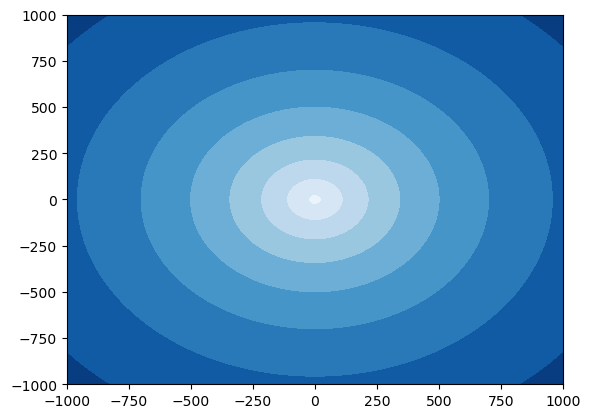

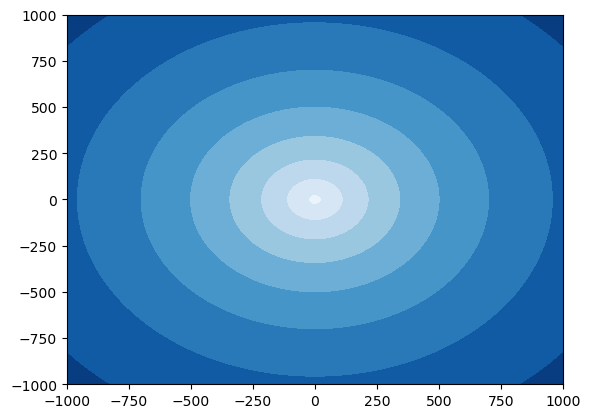

In [4]:
# try plotting potential contours
x = np.linspace(-1000, 1000, 100)
z = np.linspace(-1000, 1000, 100)
host_potential.plot_contours(grid=(x, 1., z))

In [5]:
# use gd.PhaseSpacePosition to define initial conditions and other positions in phase space, using cartesian position and velocity vectors
# pass them in with units when the potential also has unit system--you can use any length and velocity units
initial_conditions = gd.PhaseSpacePosition(pos=[400,0,0.] * u.kpc,
                                           vel=[50,1200, 100] * u.km/u.s)

# use the code below to set up initial conditions in cylindrical coordinates
# from astropy.coordinates import CylindricalRepresentation, CylindricalDifferential
# rho = 400 * u.kpc
# phi = 0*u.deg
# z = 0*u.kpc
# d_rho = 50*u.km/u.s
# d_z = 100*u.km/u.s
# v_phi_tangential = 1200*u.km/u.s
# initial_conditions = create_cylindrical_initial_conditions(rho, phi, z, d_rho, v_phi_tagential, d_z)

## Simulate an Orbit and Calculate Tail Angles

In [6]:
orbit = Orbit(host_potential, initial_conditions, n_steps=2000)

Simulating an orbit in the host potential with intial conditions position = [400.   0.   0.] kpc, velocity = [  50. 1200.  100.] km / s


In [7]:
# calculate the galaxy's 3d tail angles
orbit.calc_3d_tail_angles()

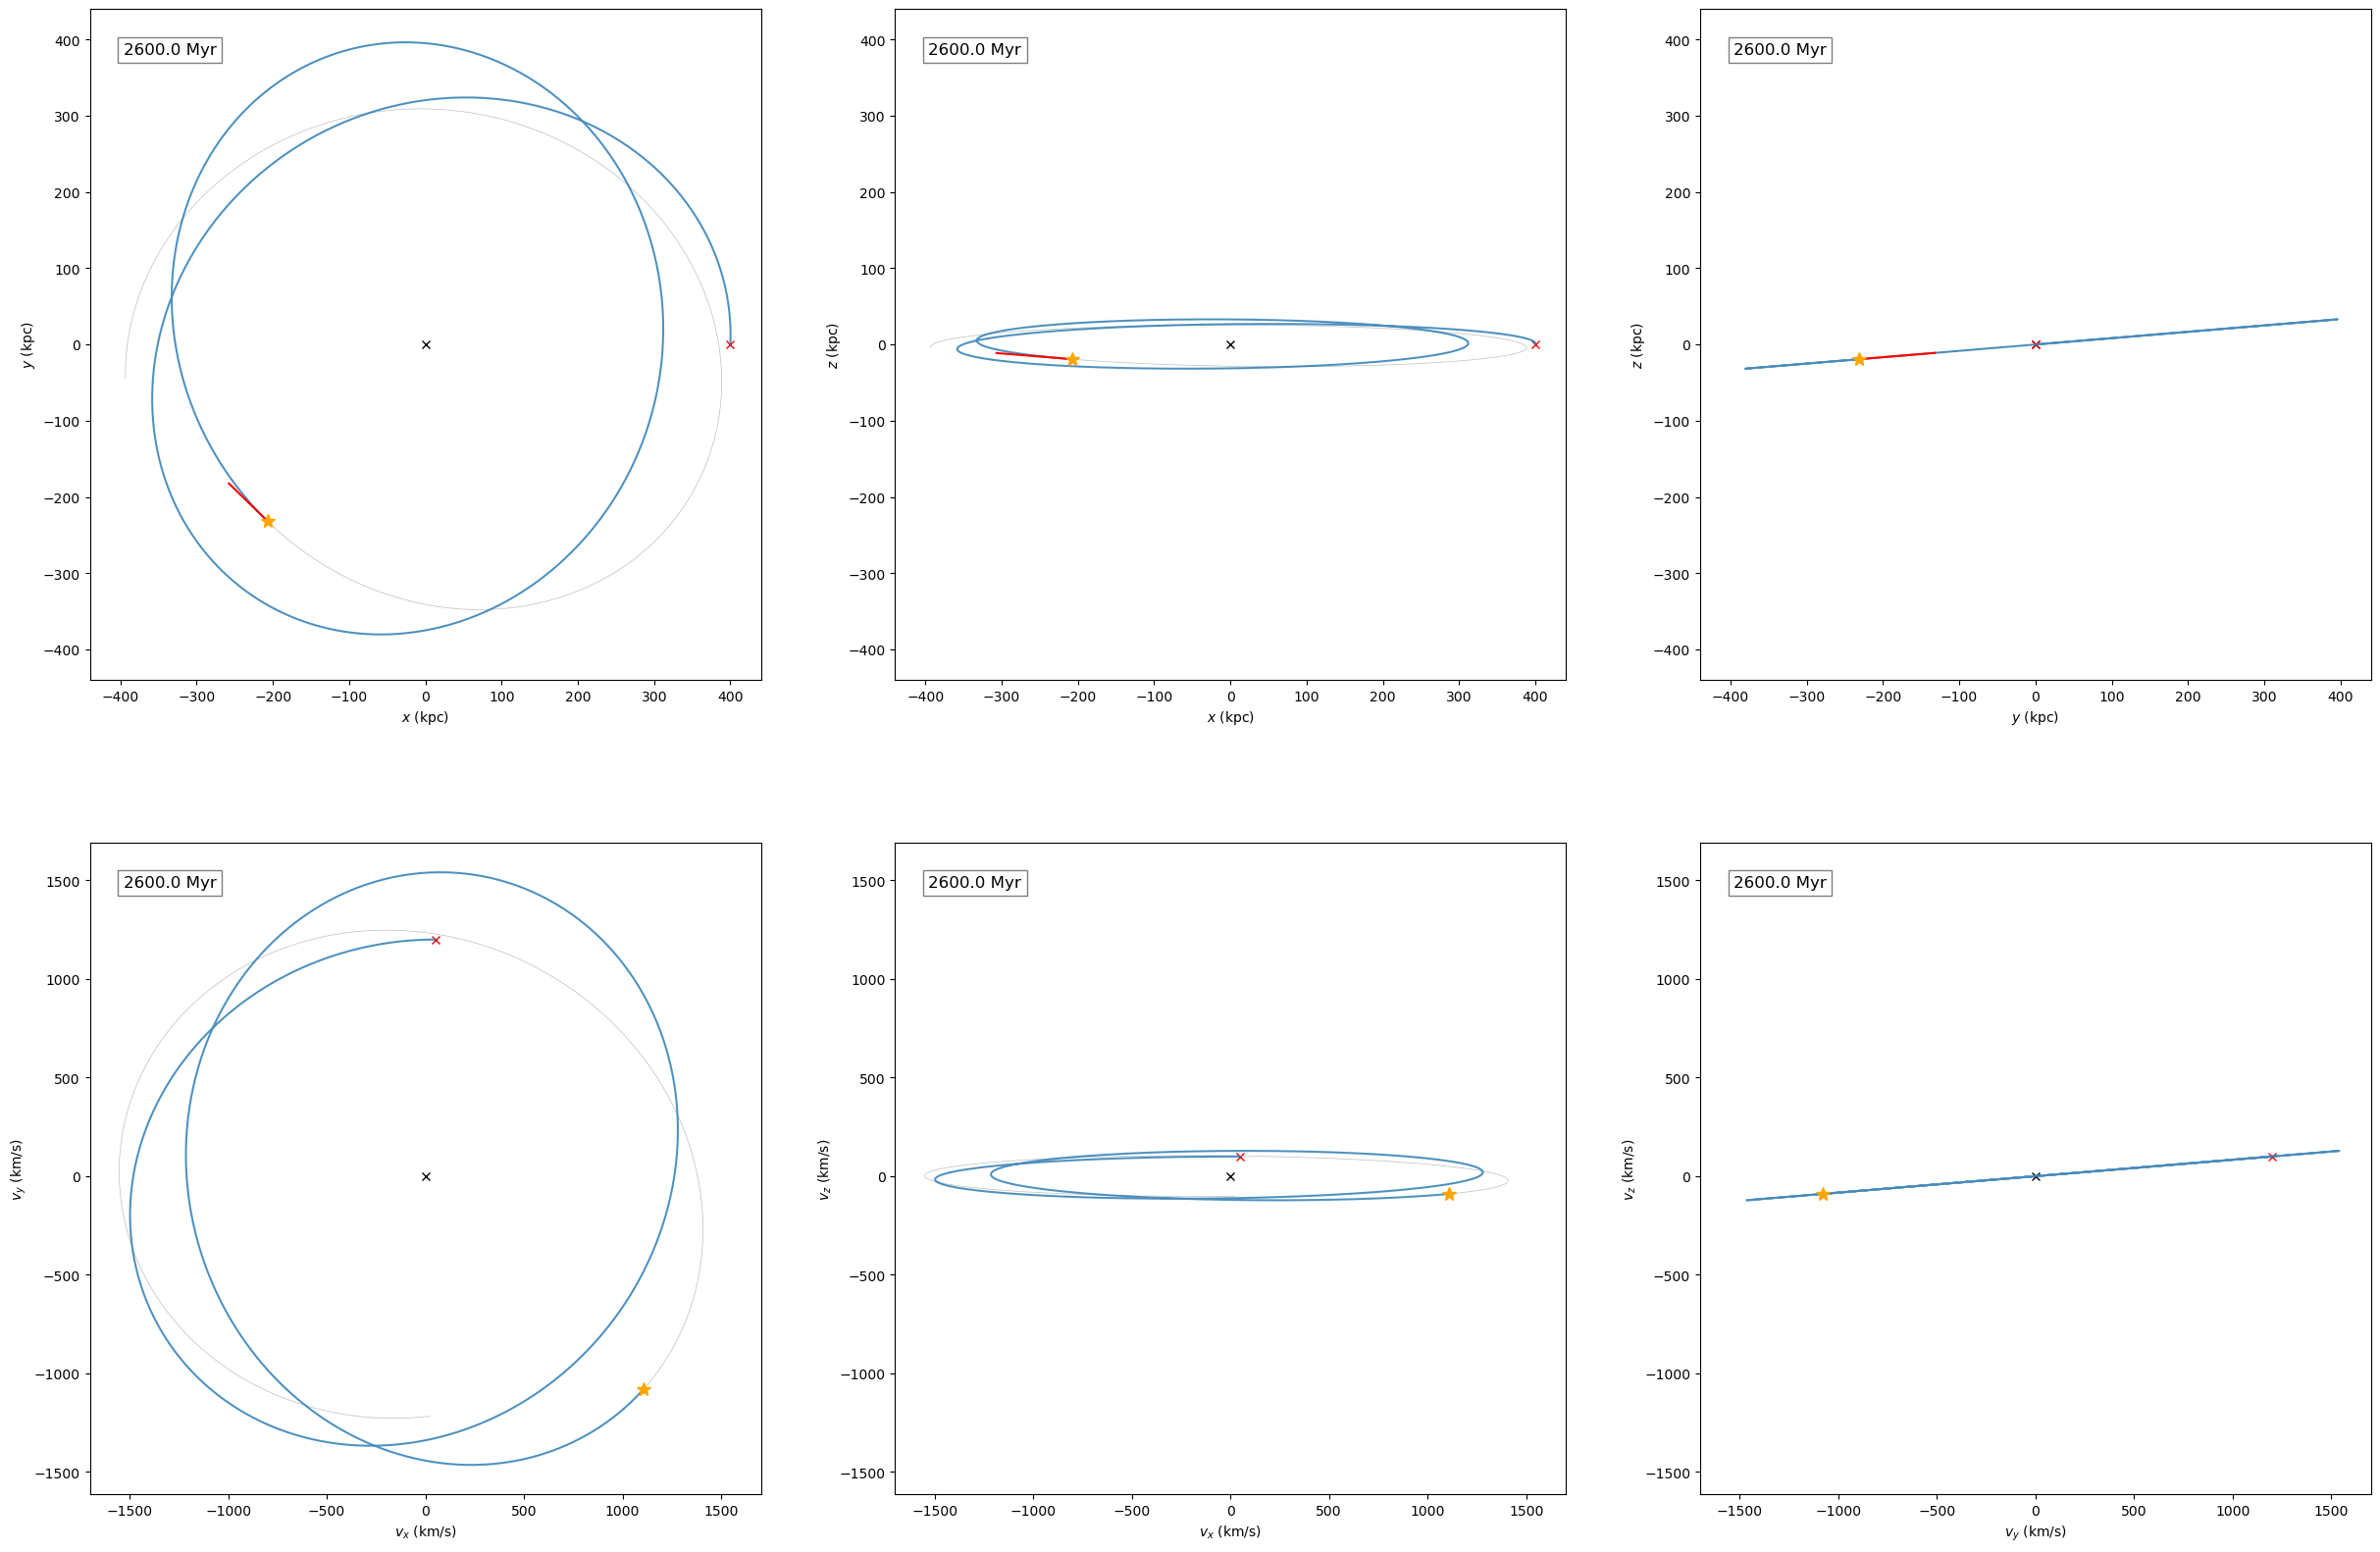

In [8]:
# plot the orbit in main Cartesian projection
# use time_index to indicate at what time you want to see the tails!
orbit.plot_orbits_not_animated(time_index=1300, with_tails=True);

In [9]:
# check out the 3D tail angle for the same time index
orbit.tail_3d_radial_angle_deg[1500]

85.31942152051931

## Projecting the Orbit Based on the Viewing Angle

In [10]:
# generate the projected 2D orbit and tail angles
# input a viewing direction vector corresponding to the direction the viewer is looking
tail_vectors_2d = orbit.project_orbit_tail_angles(view_dir = [0, 0, 1])

In [11]:
# check out the 2D tail angle at your favorite time in the orbit! 2D tail angles are measured relative to the direction to cluster center
print(tail_vectors_2d.tail_angles_2d_relative_deg[1500])

85.1226409127048


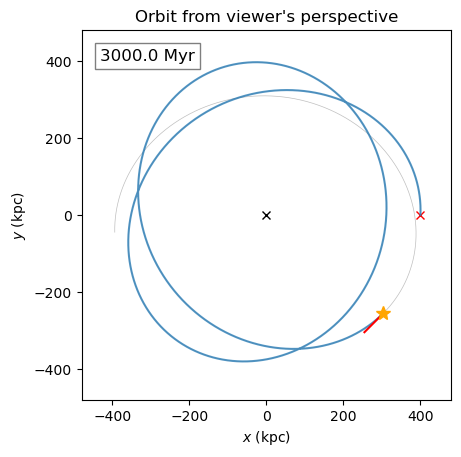

In [12]:
# plot your projected orbit
tail_vectors_2d.plot_projected_orbit(1500, with_tail=True);

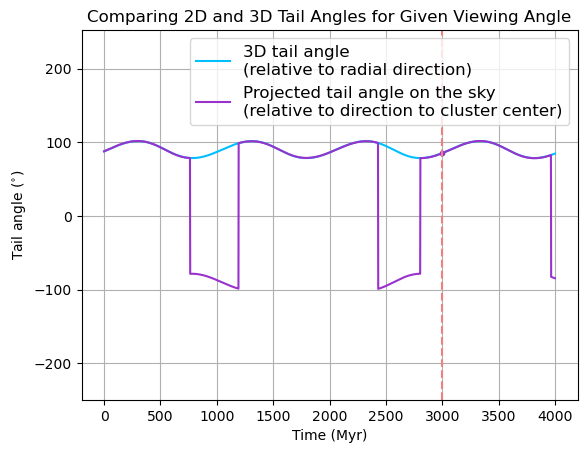

In [13]:
# compare the 2D and 3D tail angles
tail_vectors_2d.comparison_plots(1500);